# Data Decay Detection — EDA
Exploratory analysis of 92 S&P 500 stocks across 4 market regimes (2000-2024)

In [5]:
import os
os.chdir('/Users/davidji/Desktop/Projects/data-decay-detection')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('Libraries loaded!')

Libraries loaded!


In [6]:
df = pd.read_parquet('data/raw/sp500_all_stocks.parquet')
df['Date'] = pd.to_datetime(df['Date'])
print(f'Shape: {df.shape}')
print(df['Regime'].value_counts())
df.head()

Shape: (510039, 14)
Regime
bull        430000
volatile     46092
bear         33947
Name: count, dtype: int64


,Date,Open,High,Low,Close,Volume,Ticker,Sector,Daily_Return,Volatility_30d,MA_50,MA_200,Golden_Cross,Regime
0,2000-10-16,0.334275,0.348320,0.320229,0.322103,8.201760e+08,AAPL,Technology,-0.025494,0.106310,0.702211,0.793808,0,bull
1,2000-10-17,0.324912,0.328657,0.294949,0.301503,6.017200e+08,AAPL,Technology,-0.063955,0.106489,0.693878,0.791123,0,bull
2,2000-10-18,0.291203,0.315548,0.280903,0.301503,8.342656e+08,AAPL,Technology,0.000000,0.106408,0.685900,0.788791,0,bull
3,2000-10-19,0.286989,0.296821,0.274349,0.283712,1.506725e+09,AAPL,Technology,-0.059005,0.105233,0.677342,0.786315,0,bull
4,2000-10-20,0.285585,0.305248,0.283713,0.292139,7.912632e+08,AAPL,Technology,0.029701,0.105741,0.668934,0.784217,0,bull


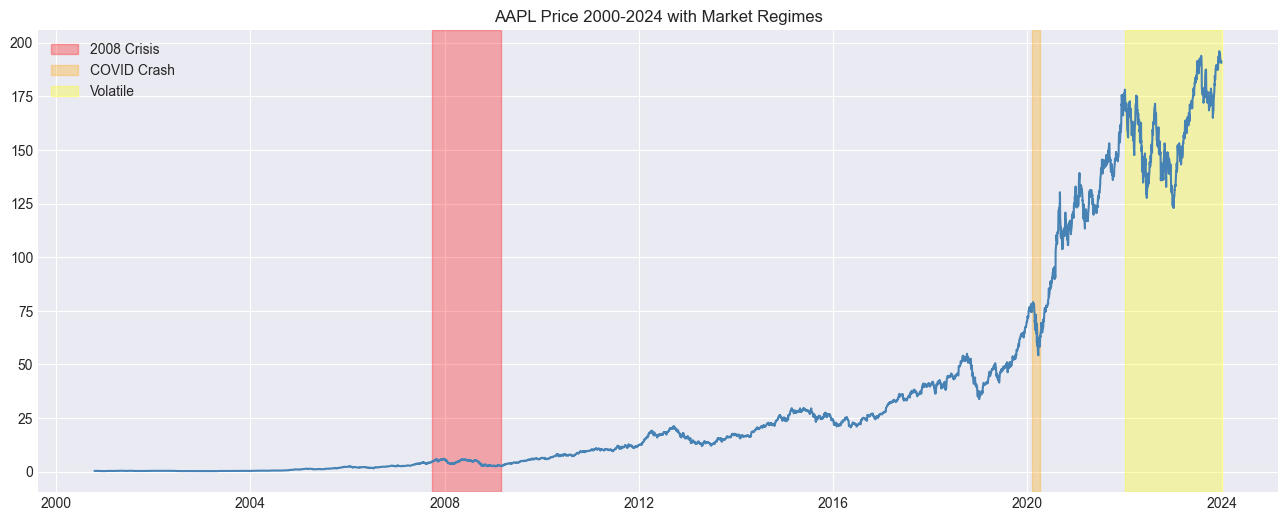

Chart 1 saved!


In [7]:
aapl = df[df['Ticker'] == 'AAPL'].copy().sort_values('Date')
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(aapl['Date'], aapl['Close'], color='steelblue', linewidth=1.5)
ax.axvspan(pd.Timestamp('2007-10-01'), pd.Timestamp('2009-03-01'), alpha=0.3, color='red', label='2008 Crisis')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'), alpha=0.3, color='orange', label='COVID Crash')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2024-01-01'), alpha=0.3, color='yellow', label='Volatile')
ax.set_title('AAPL Price 2000-2024 with Market Regimes')
ax.legend()
plt.savefig('notebooks/chart1_regimes.png', dpi=150)
plt.show()
print('Chart 1 saved!')

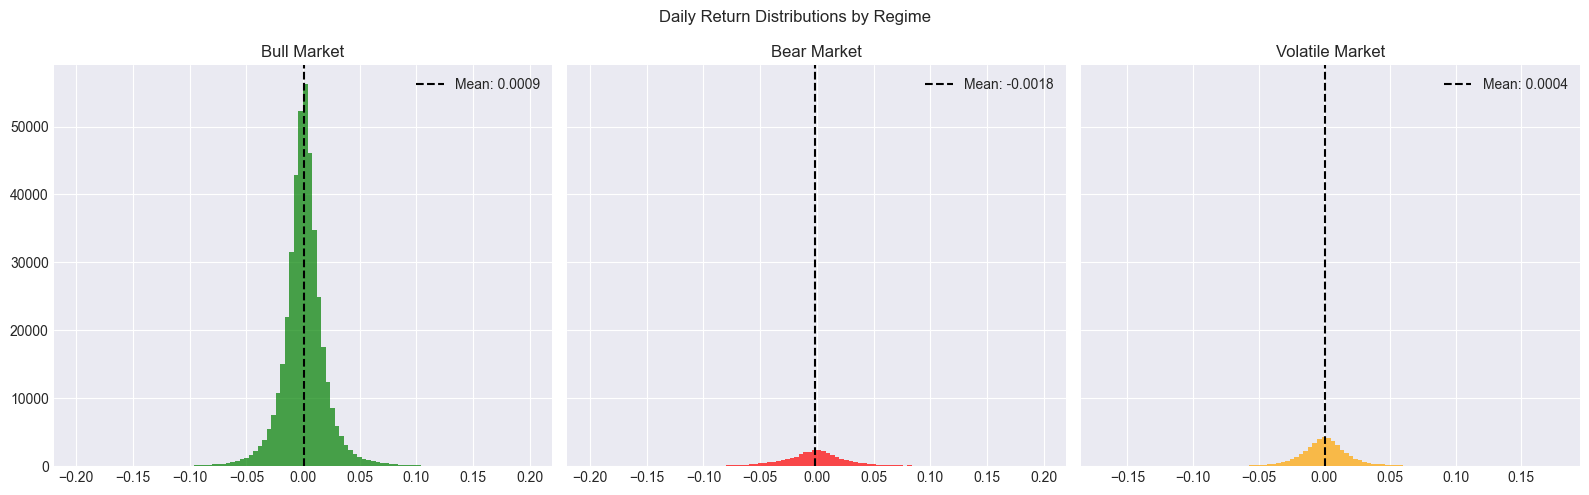

Chart 2 saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, regime, color in zip(axes, ['bull', 'bear', 'volatile'], ['green', 'red', 'orange']):
    data = df[df['Regime'] == regime]['Daily_Return'].dropna()
    data = data[data.between(-0.2, 0.2)]
    ax.hist(data, bins=100, color=color, alpha=0.7)
    ax.axvline(data.mean(), color='black', linestyle='--', label=f'Mean: {data.mean():.4f}')
    ax.set_title(f'{regime.capitalize()} Market')
    ax.legend()
plt.suptitle('Daily Return Distributions by Regime')
plt.tight_layout()
plt.savefig('notebooks/chart2_returns.png', dpi=150)
plt.show()
print('Chart 2 saved!')

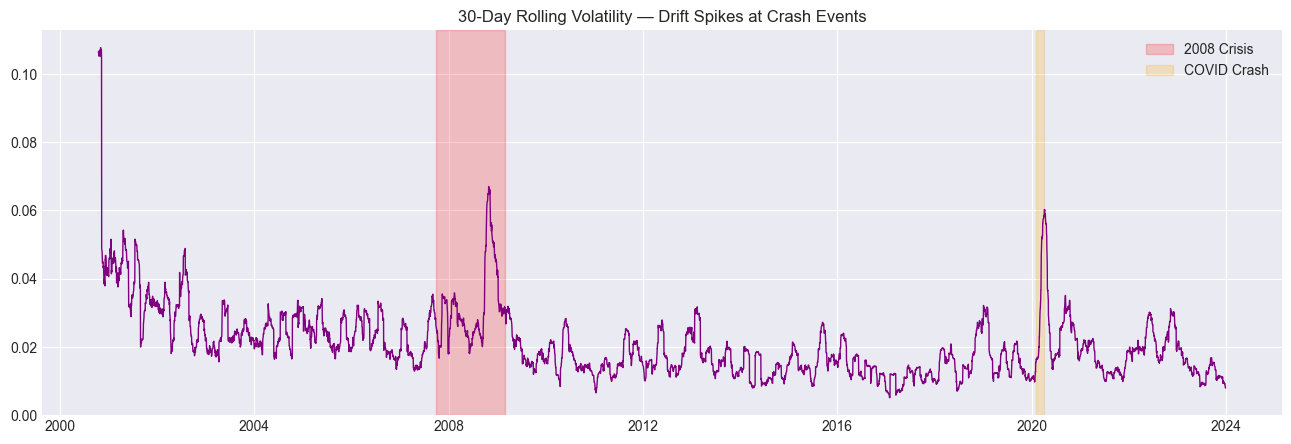

Chart 3 saved!


In [9]:
aapl_vol = df[df['Ticker'] == 'AAPL'].copy().sort_values('Date')
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(aapl_vol['Date'], aapl_vol['Volatility_30d'], color='purple', linewidth=1)
ax.axvspan(pd.Timestamp('2007-10-01'), pd.Timestamp('2009-03-01'), alpha=0.2, color='red', label='2008 Crisis')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'), alpha=0.2, color='orange', label='COVID Crash')
ax.set_title('30-Day Rolling Volatility — Drift Spikes at Crash Events')
ax.legend()
plt.savefig('notebooks/chart3_volatility.png', dpi=150)
plt.show()
print('Chart 3 saved!')

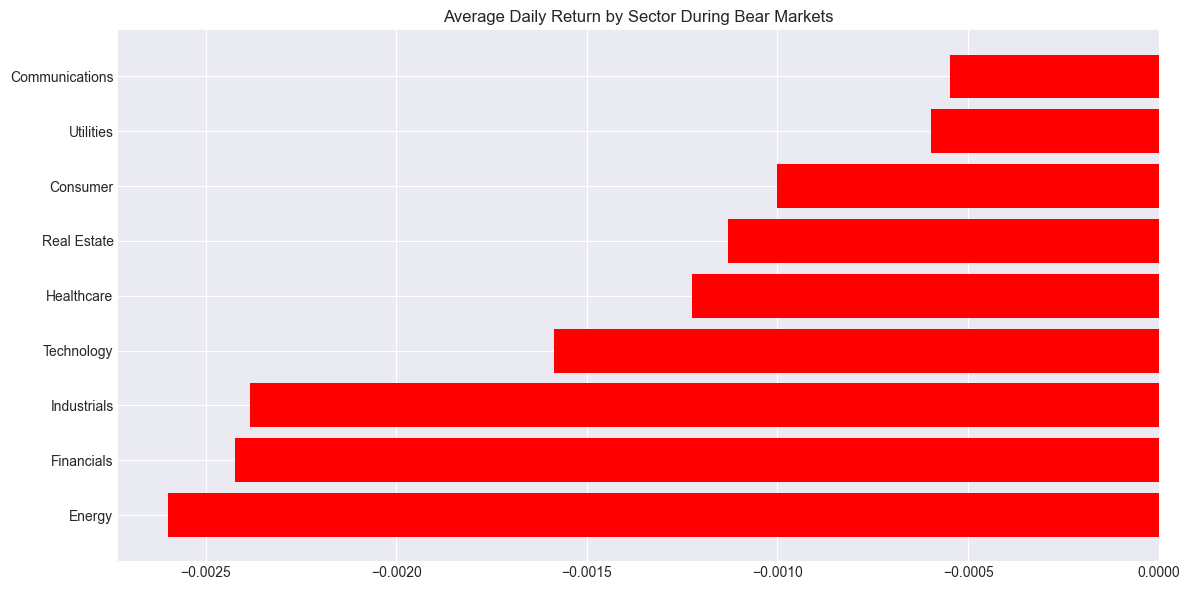

Chart 4 saved!


In [10]:
crisis = df[df['Regime'] == 'bear']
sector_returns = crisis.groupby('Sector')['Daily_Return'].mean().sort_values()
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['red' if x < 0 else 'green' for x in sector_returns.values]
ax.barh(sector_returns.index, sector_returns.values, color=colors)
ax.set_title('Average Daily Return by Sector During Bear Markets')
plt.tight_layout()
plt.savefig('notebooks/chart4_sectors.png', dpi=150)
plt.show()
print('Chart 4 saved!')

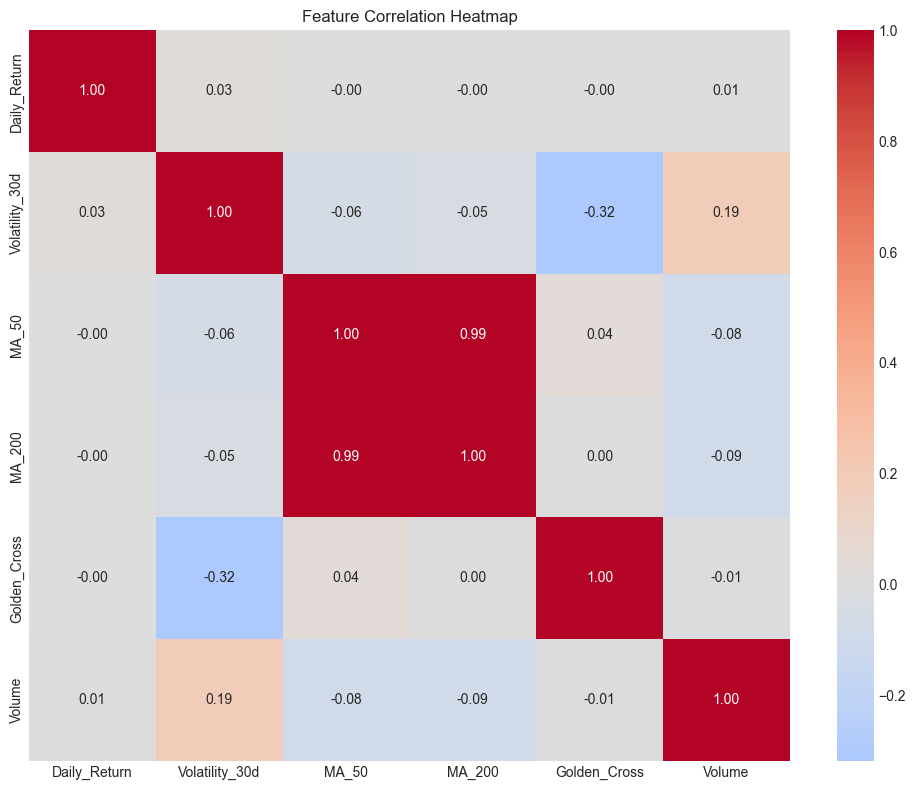

Chart 5 saved!


In [11]:
features = ['Daily_Return', 'Volatility_30d', 'MA_50', 'MA_200', 'Golden_Cross', 'Volume']
corr = df[features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('notebooks/chart5_correlation.png', dpi=150)
plt.show()
print('Chart 5 saved!')